In [17]:
import pandas as pd
import easygui
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from numpy.random import random
from plotly.subplots import make_subplots
import os

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.preprocessing import PolynomialFeatures


In [6]:
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDOneClassSVM
from sklearn.svm import OneClassSVM

In [11]:
features = easygui.fileopenbox(filetypes="*.txt",multiple=True)

In [89]:
data_load = []
def way_to_data():
    root_dir = 'C:\\Users\\USER\\Desktop\\lec\\features\\temperature data\\'
    all_files = []
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            # Сформируйте полный путь к файлу
            full_path = os.path.join(dirpath, filename)
            if 'csv' in full_path:
                data_load.append(full_path)

In [372]:
data_load[0].split('-')[1]

'Т13КО'

In [91]:
way_to_data()

In [121]:
data = defaultdict(list)
mseComparison = defaultdict(list)

In [123]:
def data_sets():
    for name in data_load:
        csv = pd.DataFrame()
        csv[name.split('-')[1]] = pd.read_csv(name)['max']
        csv['payload'] = pd.read_csv(features[1])['max'].iloc[:3805]
        csv['north'] = pd.read_csv(features[0])['max'].iloc[:3805]
        csv['south'] = pd.read_csv(features[2])['max'].iloc[:3805]
        csv['LiquidSystem'] = list(np.ones(2903)) + list(np.ones(901)/2)
        csv['payloadCurrent'] = pd.read_csv(features[3])['max'].iloc[:3805]
        data[name.split('-')[1]].append(csv)

In [125]:
data_sets()

## Supervised learning

In [129]:
def unsupervised():
    for i in range(len(data.keys())):
        #data
        X = data[list(data.keys())[i]][0][['payload','north','south', 'LiquidSystem', 'payloadCurrent']]
        y = data[list(data.keys())[i]][0][[list(data.keys())[i]]]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        #linear
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        mseComparison['line'].append(mse)
                
        # random forest
        rf_model = RandomForestRegressor(n_estimators=100)
        rf_model.fit(X_train, y_train.values.ravel())
        y_pred_rf = rf_model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred_rf)
        mseComparison['random'].append(mse)
        
        # gradient boost
        rf_model = GradientBoostingRegressor()
        rf_model.fit(X_train, y_train.values.ravel())
        y_pred_rf = rf_model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred_rf)
        mseComparison['gradient boost'].append(mse)
        
        #polynomial
        model_poly = make_pipeline(PolynomialFeatures(degree=4), LinearRegression())
        model_poly.fit(X_train, y_train)
        y_pred_poly = model_poly.predict(X_test)
        mse = mean_squared_error(y_test, y_pred_poly)
        mseComparison['poly'].append(mse)
        
        #decision tree
        tree_reg = DecisionTreeRegressor(random_state=42)
        tree_reg.fit(X_train, y_train)
        y_pred_dt = tree_reg.predict(X_test)
        mse = mean_squared_error(y_test, y_pred_dt)
        mseComparison['dtree'].append(mse)

In [131]:
unsupervised()

In [132]:
print(len([x for x in mseComparison['line'] if x <2.5]))
print(len([x for x in mseComparison['random'] if x <2.5]))
print(len([x for x in mseComparison['gradient boost'] if x <2.5]))
print(len([x for x in mseComparison['poly'] if x <2.5]))
print(len([x for x in mseComparison['dtree'] if x <2.5]))

11
106
105
99
105


In [342]:
#import joblib
for i in range(len(data.keys())):
    #data
    X = data[list(data.keys())[i]][0][['payload','north','south', 'LiquidSystem', 'payloadCurrent']]
    y = data[list(data.keys())[i]][0][[list(data.keys())[i]]]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    rf_model = GradientBoostingRegressor()
    rf_model.fit(X_train, y_train.values.ravel())
    y_pred_rf = rf_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred_rf)
    joblib.dump(rf_model, f'models\\{list(data.keys())[i]}')

In [356]:
from sklearn.ensemble import HistGradientBoostingRegressor
for i in range(len(data.keys())):
    X = data[list(data.keys())[i]][0][['payload','north','south', 'LiquidSystem', 'payloadCurrent']]
    y = data[list(data.keys())[i]][0][[list(data.keys())[i]]]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    # допустим: ожидаем рост по f1 и f2, остальные без требования
    monotonic = [1, 1, 1, 0, 1]
    
    gb = HistGradientBoostingRegressor(monotonic_cst=monotonic)
    gb.fit(X_train, y_train)
    y_pred = gb.predict(X_test)
    joblib.dump(gb, f'models\\{list(data.keys())[i]}')

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validati

## Prediction models


In [358]:
loadModels = easygui.fileopenbox(multiple=True)

In [360]:
Payload = pd.read_csv('features\\Payload.csv')['max'].values
North = pd.read_csv('features\\North.csv')['max'].values
South = pd.read_csv('features\\South.csv')['max'].values
TWT = pd.read_csv('features\\TWT Current.csv')['max'].values

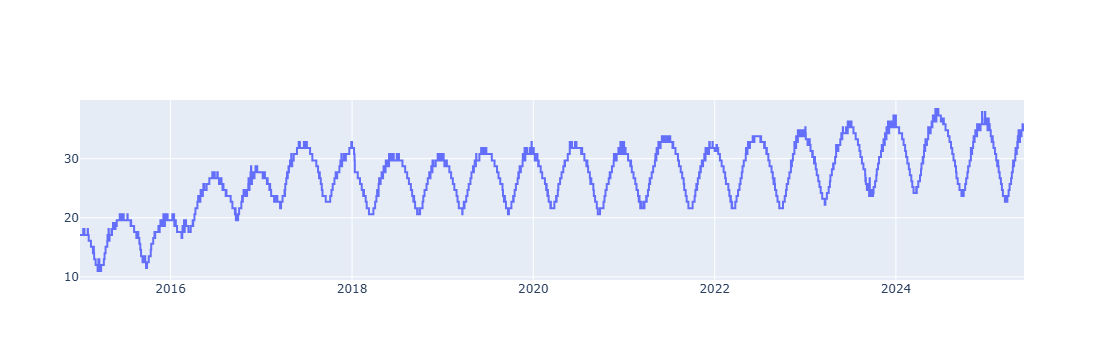

In [362]:
fig = go.Figure()
#fig.add_trace(go.Scatter(x = pd.read_csv('features\\Payload.csv')['date'], 
#                         y = data[list([x for x in data.keys() if 'Ж' in x])[0]][0][list([x for x in data.keys() if 'Ж' in x])[0]]
#                         , mode = 'lines',line_shape='hv'
#                        , name = list([x for x in data.keys() if 'Ж' in x])[0]))
fig.add_trace(go.Scatter(x = pd.read_csv('features\\Payload.csv')['date'], 
                         y = data['Т2Ж'][0]['Т2Ж']
                         , mode = 'lines',line_shape='hv'
                        , name = 'Т2Ж'))

In [310]:
[x for x in loadModels if 'Т26СПП' in x]

['C:\\Users\\USER\\Desktop\\lec\\models\\Т26СПП']

In [364]:
for k in np.arange(1,14):
    #Liquid = list(np.ones(2903)) + list(np.ones(901)/2) + list(np.ones(100*k)/2) + list(np.zeros(1429-(100*k)))
    Liquid = list(np.ones(2903)) + list(np.ones(901)/2) + list(np.ones(1429)/2)
    X = np.array([Payload,North,South,Liquid,TWT]).T
    model_test = joblib.load([x for x in loadModels if 'Т2Ж' in x][0])
    prediction = model_test.predict(X)
    fig.add_trace(go.Scatter(x = pd.read_csv('features\\Payload.csv')['date'], y = prediction, mode = 'lines',line_shape='hv'
                             , name = f'{k} Т2Ж'))

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names

C:\Users\USER\anaconda3\Lib\site-package

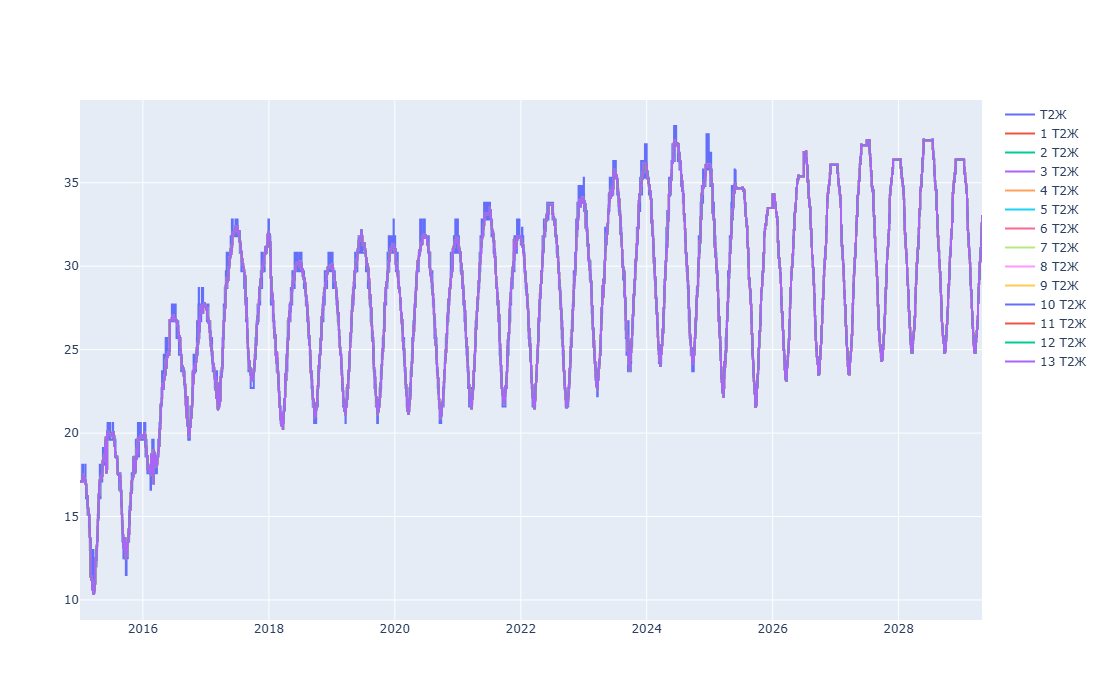

In [365]:
fig.update_layout(width=1100,  height=700)
fig.show()